# Can we recover missing Mucin 2 and Glucagon labels?

Evaluate saved classifiers on held-out organoids. Compare center-only features with shared-marker fractions through radii 1–4, with or without center Gaussian curvature. The targets are measured binary stains before exclusivity. Neither hidden target channel enters any classifier's input.

The main criterion is recovery at high precision, rather than accuracy dominated by negatives. Show precision–recall discrimination, actual performance of calibration-selected thresholds, and how many false-positive cells are introduced per organoid. Whole-organoid bootstrap intervals condition on these fitted models. Five folds do not constitute five independent experiments, and no positive-label validation is possible in the unstained experiment. Curvature-assisted results cannot justify later interpreting restored marker–curvature associations as independent biological evidence.

This notebook loads saved inputs and predictions; it does not fit classifiers, change the datasets, or assign missing identities.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src').is_dir())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

## Configuration

Use the explicit completed marker-prediction run. The precision target switches which calibration-selected thresholds are displayed; test labels are never used to select these thresholds. The fixed illustrative radius controls the count and calibration diagnostic only, not training or model selection.

In [2]:
# Saved run and display choices
RUN_DIR = PROJECT_ROOT / 'training_results/marker_prediction_training/shared_panel_r0to4_gaussian_20261006_114829'  # Completed classifier grid.
PRECISION_TARGET = .95  # Calibration precision target to display; .90 is also available.
ILLUSTRATION_RADIUS = 4  # Fixed radius for count and reliability diagnostics, not selected using test performance.

# Conditional uncertainty
N_BOOTSTRAP = 1000  # Resample whole test organoids for operating-point intervals.
SEED = 42  # Reproducible bootstrap sampling.

# Outputs
OUTPUT_DIR = RUN_DIR / 'evaluation'  # Figures and aggregated test tables.


## Restore labels, support and held-out predictions

Check completeness and disjoint organoid membership. Aggregate all out-of-fold predictions so every measured cell is represented once per feature configuration. Retain the original fold-specific calling thresholds for deployment-style performance; a single threshold tuned on pooled test labels would be optimistic.

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import average_precision_score, precision_recall_curve, brier_score_loss
from sklearn.calibration import calibration_curve
from src.marker_prediction.evaluation import bootstrap_precision_recall

assert (RUN_DIR / 'complete.json').exists(), 'Training must finish before evaluation.'
settings = json.loads((RUN_DIR / 'settings.json').read_text())
assert PRECISION_TARGET in settings['precision_targets']
markers, radii = settings['target_markers'], settings['radii']
cohort = pd.read_csv(RUN_DIR / 'cohort.csv')
metrics = pd.read_csv(RUN_DIR / 'test_metrics.csv')
calls = pd.read_csv(RUN_DIR / 'organoid_calls.csv')
splits = json.loads((RUN_DIR / 'splits.json').read_text())
measured = cohort[cohort[[f'measured_{m}' for m in markers]].all(axis=1)]
assert sorted(g for s in splits for g in s['test']) == sorted(measured.graph_id.tolist())
for s in splits:
    assert not (set(s['train']) & set(s['calibration']) or set(s['train']) & set(s['test']) or set(s['calibration']) & set(s['test']))
expected_models = len(markers)*len(radii)*len(settings['curvature_variants'])*len(splits)
assert len(metrics) == expected_models*len(settings['precision_targets'])
OUTPUT_DIR.mkdir(exist_ok=True)
pooled = {}
rows = []
for marker_index, marker in enumerate(markers):
    for radius in radii:
        for curvature in settings['curvature_variants']:
            parts = []
            for split in splits:
                key = f'target{marker_index}_r{radius}_curvature{int(curvature)}_f{split["fold"]}'
                values = np.load(RUN_DIR / 'predictions' / f'{key}.npz')
                assert set(np.unique(values['graph_ids'])) == set(split['test'])
                parts.append(pd.DataFrame(dict(row_index=values['row_indices'], graph_id=values['graph_ids'],
                    y=values['labels'], probability=values['probabilities'], fold=split['fold'])))
            frame = pd.concat(parts, ignore_index=True).sort_values('row_index')
            assert not frame.row_index.duplicated().any() and frame.y.ge(0).all()
            assert len(frame) == measured.n_cells.sum()
            pooled[(marker, radius, curvature)] = frame
            rows.append(dict(marker=marker, radius=radius, use_curvature=curvature,
                average_precision=average_precision_score(frame.y, frame.probability),
                prevalence=frame.y.mean(), brier=brier_score_loss(frame.y, frame.probability)))
summary = pd.DataFrame(rows)
summary.to_csv(OUTPUT_DIR / 'discrimination.csv', index=False)
support_rows = []
for marker in markers:
    eligible = cohort[cohort[f'measured_{marker}']]
    support_rows.append(dict(marker=marker, measured_organoids=len(eligible), cells=int(eligible.n_cells.sum()),
        positive_cells=int(eligible[f'positive_{marker}'].sum()), positive_organoids=int((eligible[f'positive_{marker}']>0).sum()),
        prevalence=float(eligible[f'positive_{marker}'].sum()/eligible.n_cells.sum())))
support = pd.DataFrame(support_rows)
support.to_csv(OUTPUT_DIR / 'label_support.csv', index=False)
display(support)
COLORS = {False:'#2c6aab', True:'#d1742d'}
LABELS = {False:'Shared markers only', True:'Shared markers + center curvature'}


,marker,measured_organoids,cells,positive_cells,positive_organoids,prevalence
0,Mucin 2,1207,432072,8637,916,0.019990
1,Glucagon,1207,432072,185,93,0.000428


## How much predictive information do neighborhoods add?

Average precision summarizes the precision–recall curve; its prevalence reference is very low for rare markers. Thick curves use pooled held-out predictions, and thin lines show each fold. A high enrichment over prevalence does not imply that individual positive calls are sufficiently reliable for restoration.

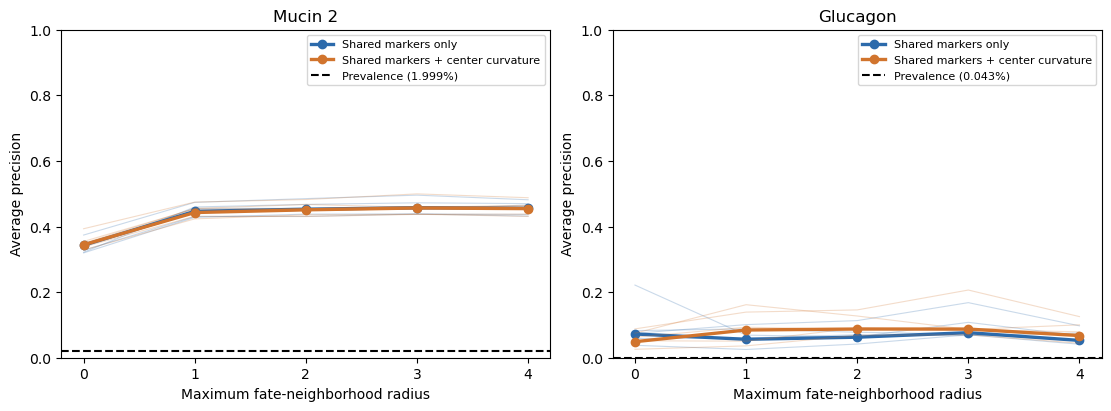

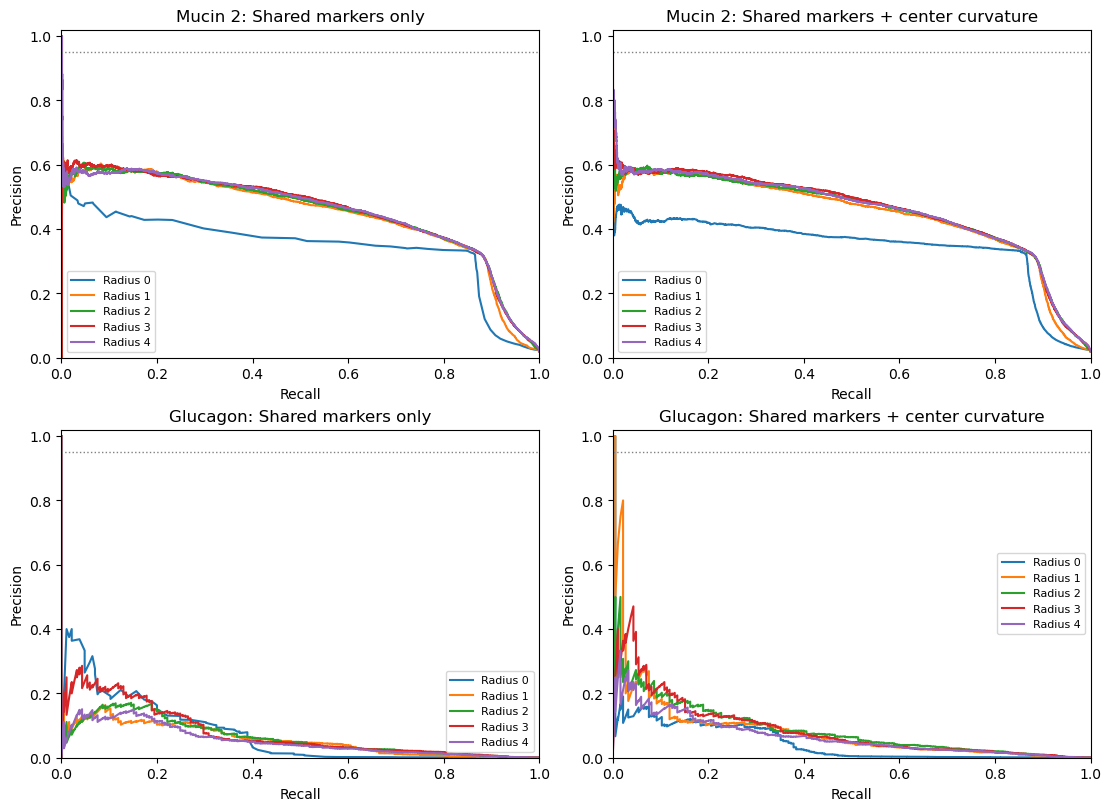

In [4]:
fig, axes = plt.subplots(1, len(markers), figsize=(11, 4), squeeze=False, layout='constrained')
unique_metrics = metrics.drop_duplicates(['marker', 'radius', 'use_curvature', 'fold'])
for ax, marker in zip(axes.flat, markers):
    for curvature in settings['curvature_variants']:
        group = unique_metrics[(unique_metrics.marker == marker) & (unique_metrics.use_curvature == curvature)]
        for _, fold in group.groupby('fold'):
            fold = fold.sort_values('radius')
            ax.plot(fold.radius, fold.average_precision, color=COLORS[curvature], alpha=.25, lw=.8)
        s = summary[(summary.marker == marker) & (summary.use_curvature == curvature)].sort_values('radius')
        ax.plot(s.radius, s.average_precision, 'o-', color=COLORS[curvature], lw=2.4, label=LABELS[curvature])
    prevalence = float(support.loc[support.marker == marker, 'prevalence'].iloc[0])
    ax.axhline(prevalence, color='black', ls='--', label=f'Prevalence ({prevalence:.3%})')
    ax.set(title=marker, xlabel='Maximum fate-neighborhood radius', ylabel='Average precision', xticks=radii, ylim=(0,1))
    ax.legend(fontsize=8)
fig.savefig(OUTPUT_DIR / 'average_precision_by_radius.png', dpi=180)
plt.show()
fig, axes = plt.subplots(len(markers), 2, figsize=(11, 4*len(markers)), squeeze=False, layout='constrained')
for row, marker in enumerate(markers):
    for col, curvature in enumerate(settings['curvature_variants']):
        ax = axes[row,col]
        for radius in radii:
            f = pooled[(marker,radius,curvature)]
            precision, recall, _ = precision_recall_curve(f.y, f.probability)
            ax.plot(recall, precision, label=f'Radius {radius}', lw=1.5)
        ax.axhline(PRECISION_TARGET, color='grey', ls=':', lw=1)
        ax.set(title=f'{marker}: {LABELS[curvature]}', xlabel='Recall', ylabel='Precision', xlim=(0,1), ylim=(0,1.02))
        ax.legend(fontsize=8)
fig.savefig(OUTPUT_DIR / 'precision_recall_curves.png', dpi=180)
plt.show()

## Can calibration-selected calls remain precise on test organoids?

Evaluate the frozen threshold from each fold's calibration organoids. Report actual held-out precision and recall, false positives per 1,000 cells, the number of folds with a supported threshold, and whole-organoid bootstrap intervals. When a threshold is unsupported, that fold makes no positive calls. If no folds call positives, precision is undefined, not 100%; missing points in the precision plot are labelled accordingly.

Intervals condition on the fitted models and thresholds. They do not account for transfer to a differently stained experiment. Both 90% and 95% calibration targets are exported even when only one is plotted.

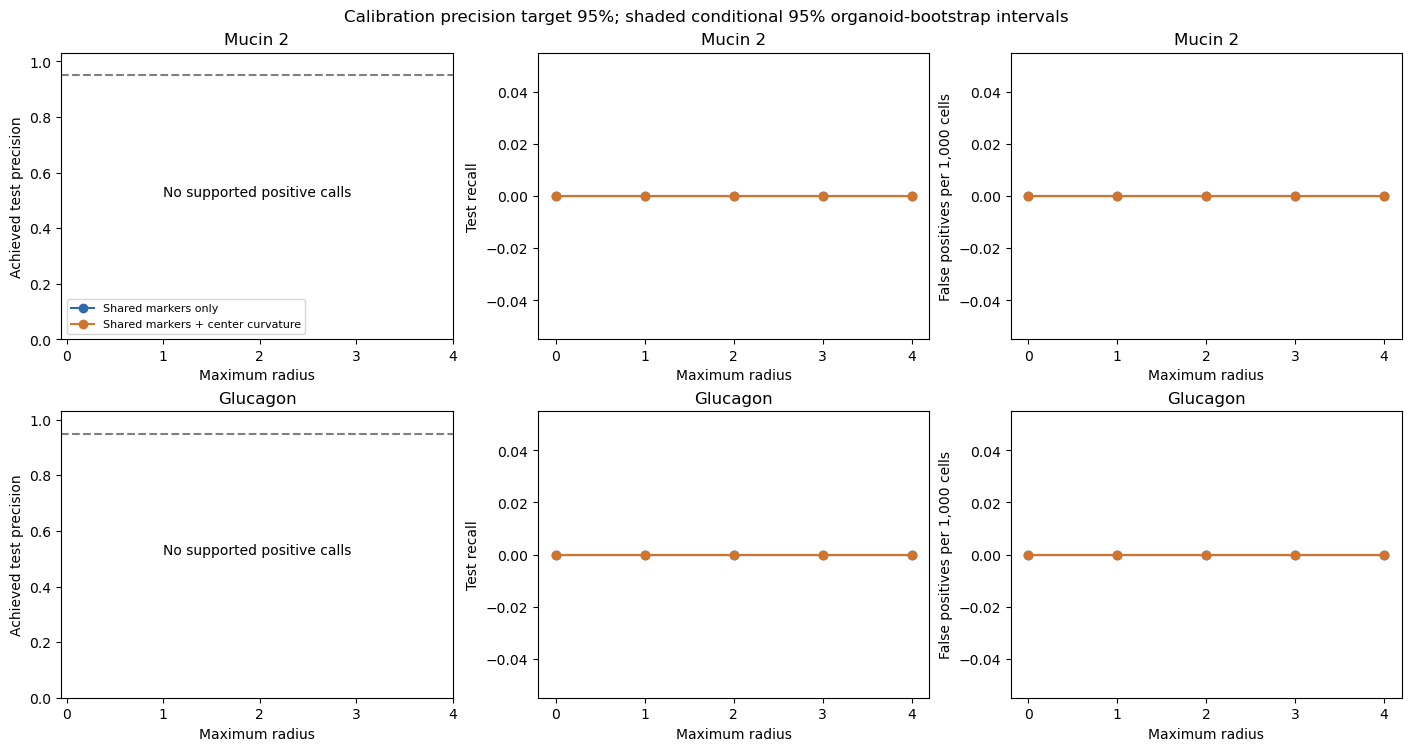

,marker,use_curvature,precision_target,supported_folds,calls,precision,recall,false_positives,maximum_false_positives_one_organoid
16,Glucagon,False,0.90,0,0,NaN,0.0,0,0
17,Glucagon,False,0.95,0,0,NaN,0.0,0,0
18,Glucagon,True,0.90,0,0,NaN,0.0,0,0
19,Glucagon,True,0.95,0,0,NaN,0.0,0,0
36,Mucin 2,False,0.90,0,0,NaN,0.0,0,0
37,Mucin 2,False,0.95,0,0,NaN,0.0,0,0
38,Mucin 2,True,0.90,0,0,NaN,0.0,0,0
39,Mucin 2,True,0.95,0,0,NaN,0.0,0,0


In [5]:
operating_rows = []
for (marker, radius, curvature, target), group in calls.groupby(['marker','radius','use_curvature','precision_target']):
    assert not group.graph_id.duplicated().any()
    tp, fp, positives, n = [group[c].sum() for c in ('tp','fp','positives','n_cells')]
    m = metrics[(metrics.marker == marker) & (metrics.radius == radius) & (metrics.use_curvature == curvature) & (metrics.precision_target == target)]
    negative_organoids = group[group.positives == 0]
    operating_rows.append(dict(marker=marker, radius=radius, use_curvature=curvature, precision_target=target,
        precision=tp/(tp+fp) if tp+fp else np.nan, recall=tp/positives, fp_per_1000=1000*fp/n,
        calls=int(tp+fp), true_positives=int(tp), false_positives=int(fp),
        supported_folds=int(m.threshold.notna().sum()),
        negative_organoids=len(negative_organoids), negative_organoids_with_calls=int((negative_organoids.calls>0).sum()),
        maximum_false_positives_one_organoid=int(group.fp.max()),
        **bootstrap_precision_recall(group, N_BOOTSTRAP, SEED)))
operating = pd.DataFrame(operating_rows)
operating.to_csv(OUTPUT_DIR / 'operating_points.csv', index=False)
shown = operating[operating.precision_target == PRECISION_TARGET]
fig, axes = plt.subplots(len(markers), 3, figsize=(14, 3.7*len(markers)), squeeze=False, layout='constrained')
for row, marker in enumerate(markers):
    for col, (metric, label) in enumerate([('precision','Achieved test precision'), ('recall','Test recall'), ('fp_per_1000','False positives per 1,000 cells')]):
        ax = axes[row,col]
        for curvature in settings['curvature_variants']:
            s = shown[(shown.marker == marker) & (shown.use_curvature == curvature)].sort_values('radius')
            ax.plot(s.radius,s[metric],'o-',color=COLORS[curvature],label=LABELS[curvature])
            ax.fill_between(s.radius,s[metric+'_low'],s[metric+'_high'],color=COLORS[curvature],alpha=.15)
        if metric=='precision':
            ax.axhline(PRECISION_TARGET,color='grey',ls='--')
            ax.set_ylim(0,1.03)
            if shown[shown.marker==marker].precision.isna().all():
                ax.text(.5,.5,'No supported positive calls',transform=ax.transAxes,ha='center')
        ax.set(title=marker,xlabel='Maximum radius',ylabel=label,xticks=radii)
axes[0,0].legend(fontsize=8)
fig.suptitle(f'Calibration precision target {PRECISION_TARGET:.0%}; shaded conditional 95% organoid-bootstrap intervals')
fig.savefig(OUTPUT_DIR / f'operating_points_p{PRECISION_TARGET:.2f}.png',dpi=180)
plt.show()
display(operating[operating.radius==ILLUSTRATION_RADIUS][['marker','use_curvature','precision_target','supported_folds','calls','precision','recall','false_positives','maximum_false_positives_one_organoid']])

## Sparsity and per-organoid counts

At the fixed illustrative radius, compare measured counts with high-confidence calls and with the sum of predicted probabilities. Probability sums estimate expected counts, not discrete restored identities. A model can estimate counts tolerably while failing to identify which particular cells are positive. The false-positive table includes organoids with no measured positives, where accidental restoration is especially apparent.

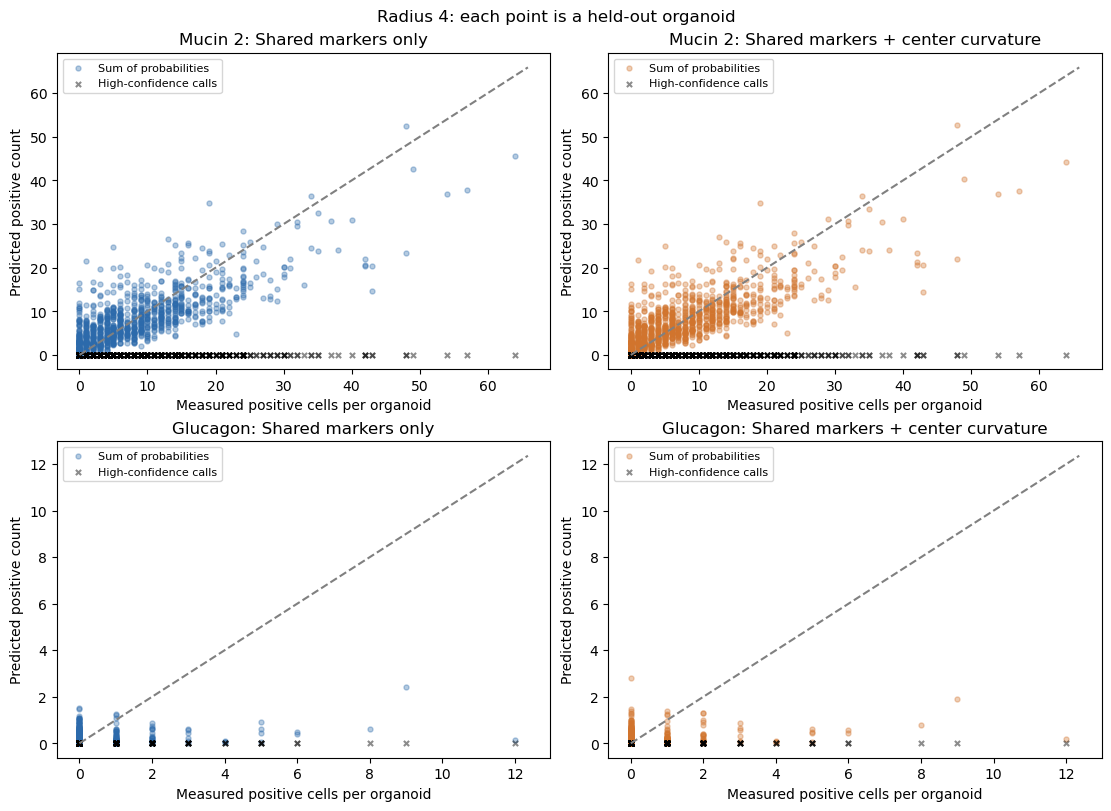

In [6]:
fig,axes=plt.subplots(len(markers),2,figsize=(11,4*len(markers)),squeeze=False,layout='constrained')
for row,marker in enumerate(markers):
    for col,curvature in enumerate(settings['curvature_variants']):
        ax=axes[row,col]
        group=calls[(calls.marker==marker)&(calls.radius==ILLUSTRATION_RADIUS)&(calls.use_curvature==curvature)&(calls.precision_target==PRECISION_TARGET)]
        ax.scatter(group.positives,group.expected_positives,s=13,alpha=.35,label='Sum of probabilities',color=COLORS[curvature])
        ax.scatter(group.positives,group.calls,s=14,alpha=.45,label='High-confidence calls',marker='x',color='black')
        limit=max(group.positives.max(),group.expected_positives.max(),group.calls.max(),1)*1.03
        ax.plot([0,limit],[0,limit],'--',color='grey')
        ax.set(title=f'{marker}: {LABELS[curvature]}',xlabel='Measured positive cells per organoid',ylabel='Predicted positive count')
        ax.legend(fontsize=8)
fig.suptitle(f'Radius {ILLUSTRATION_RADIUS}: each point is a held-out organoid')
fig.savefig(OUTPUT_DIR/'organoid_counts.png',dpi=180)
plt.show()
count_errors=[]
for keys,group in calls.groupby(['marker','radius','use_curvature','precision_target']):
    count_errors.append(dict(zip(['marker','radius','use_curvature','precision_target'],keys),
        count_mae=float(abs(group.calls-group.positives).mean()),
        expected_count_mae=float(abs(group.expected_positives-group.positives).mean()),
        **{'count_bias':float((group.calls-group.positives).mean())}))
pd.DataFrame(count_errors).to_csv(OUTPUT_DIR/'count_errors.csv',index=False)


## Calibration and cross-experiment input support

Check high-probability calibration directly on held-out cells, using fixed probability bins and exporting their counts. Rare high-confidence bins may be supported by few cells or organoids; an empty bin is not evidence of calibration. Compare shared-marker pattern frequencies between measured and unstained experiments without assigning labels to the latter. Matching inputs is necessary but cannot prove that the hidden-label relationship transfers.

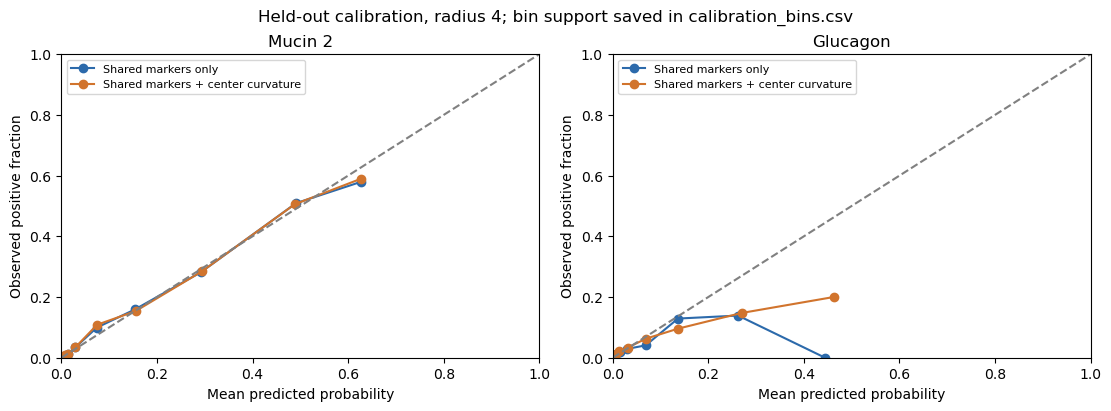

Unstained cells with center-marker patterns absent from the measured cohort: 2/117,234.
Input overlap alone does not validate transfer of Mucin 2/Glucagon predictions between experiments.


In [7]:
reliability_rows=[]
fig,axes=plt.subplots(1,len(markers),figsize=(11,4),squeeze=False,layout='constrained')
edges=np.array([0,.001,.005,.01,.02,.05,.1,.2,.4,.6,.8,.9,.95,1.000001])
for ax,marker in zip(axes.flat,markers):
    for curvature in settings['curvature_variants']:
        f=pooled[(marker,ILLUSTRATION_RADIUS,curvature)].copy()
        f['bin']=pd.cut(f.probability,edges,include_lowest=True)
        bins=f.groupby('bin',observed=True).agg(probability=('probability','mean'),observed=('y','mean'),cells=('y','size'),organoids=('graph_id','nunique')).reset_index()
        for name,value in dict(marker=marker,use_curvature=curvature,radius=ILLUSTRATION_RADIUS).items():bins[name]=value
        reliability_rows.append(bins)
        ax.plot(bins.probability,bins.observed,'o-',color=COLORS[curvature],label=LABELS[curvature])
    ax.plot([0,1],[0,1],'--',color='grey')
    ax.set(title=marker,xlabel='Mean predicted probability',ylabel='Observed positive fraction',xlim=(0,1),ylim=(0,1))
    ax.legend(fontsize=8)
fig.suptitle(f'Held-out calibration, radius {ILLUSTRATION_RADIUS}; bin support saved in calibration_bins.csv')
fig.savefig(OUTPUT_DIR/'calibration.png',dpi=180)
plt.show()
pd.concat(reliability_rows,ignore_index=True).to_csv(OUTPUT_DIR/'calibration_bins.csv',index=False)
packed=np.load(RUN_DIR/'features.npz')
shared_names=json.loads((RUN_DIR/'shared_markers.json').read_text())
x=packed['fates'][:,:len(shared_names)]
pattern=(x.astype(np.int64)*(2**np.arange(len(shared_names)))).sum(axis=1)
gids=packed['graph_ids']
is_measured=np.isin(gids,measured.graph_id)
patterns=pd.DataFrame(dict(pattern=pattern,measured=is_measured)).groupby(['measured','pattern']).size().unstack(0,fill_value=0)
patterns.columns=['unmeasured_cells' if not bool(c) else 'measured_cells' for c in patterns.columns]
for col in ['measured_cells','unmeasured_cells']:
    if col not in patterns:patterns[col]=0
patterns['shared_markers']=[', '.join(name for j,name in enumerate(shared_names) if int(i)&(1<<j)) or 'Unassigned' for i in patterns.index]
patterns['measured_fraction']=patterns.measured_cells/patterns.measured_cells.sum()
patterns['unmeasured_fraction']=patterns.unmeasured_cells/max(patterns.unmeasured_cells.sum(),1)
for j,marker in enumerate(markers):
    positives=np.bincount(pattern[is_measured],weights=(packed['labels'][is_measured,j]==1),minlength=2**len(shared_names))
    patterns[f'measured_probability_{marker}']=positives[patterns.index]/patterns.measured_cells.replace(0,np.nan)
patterns.to_csv(OUTPUT_DIR/'shared_marker_patterns.csv')
unseen=int(patterns.loc[patterns.measured_cells==0,'unmeasured_cells'].sum())
print(f'Unstained cells with center-marker patterns absent from the measured cohort: {unseen:,}/{(~is_measured).sum():,}.')
print('Input overlap alone does not validate transfer of Mucin 2/Glucagon predictions between experiments.')


## Interpretation and limitations

The radius comparison measures the incremental information in neighboring shared markers. Curvature variants measure whether local geometry helps recover missing stain labels; their predictions must remain separate from fate-only restoration. Evaluate Mucin 2 and Glucagon independently, as their label support and achievable precision can differ substantially.

The 90%/95% thresholds are selected inside each fold. If their held-out precision is low or recall is negligible, do not silently fill the unstained experiment with hard identities. The classifiers predict processed stain labels, not independently verified biological identity. All positives come from one experiment; a successful shared-marker transfer control or new staining would be needed to validate cross-experiment restoration. No labels were restored by these notebooks.

## Findings from this run

**Neighborhood information helps Mucin 2 prediction, but these models do not support reliable high-precision restoration yet.** All 100 models completed, using 1,207 measured organoids, 432,072 cells, 8,637 Mucin 2 positives and only 185 Glucagon positives. A further 276 unstained organoids were retained only for input-support diagnostics.

- **Mucin 2:** pooled held-out average precision rises from **0.343** for center-only shared markers to **0.446** at radius 1 and **0.457** at radius 3; radius 4 is **0.456**. Thus most of the neighborhood benefit comes from the first ring. Center Gaussian curvature adds no consistent improvement (radius 3: **0.456** with curvature). These are ranking metrics, not percentages of correctly identified cells.
- **Glucagon:** pooled average precision remains **0.053–0.076** without curvature and **0.049–0.087** with it. The strongest curvature-assisted configuration is radius 2 (**0.087**). Results vary across folds and only 185 positive cells support all fitting, calibration and testing. The apparent best radius is descriptive and was not independently selected/validated.
- **Sparse restoration:** no configuration in any fold meets either the 90% or 95% calibration-precision target with at least 20 predicted positives across five calibration organoids. The resulting policies abstain: zero calls, zero recall, and undefined precision. Zero false positives here indicates abstention, not successful classification. Small unsupported sets of confident predictions are deliberately not accepted.
- **Transfer:** only two unstained cells have center-marker patterns absent from the measured experiment. That input overlap does not validate the missing-marker relationships in the second experiment, nor establish neighborhood-distribution overlap.

The present models can enrich for candidate Mucin 2 cells, but the evidence does **not** justify silently restoring hard Mucin 2 or Glucagon identities in the unstained experiment. Their probabilities could instead prioritize cells for further inspection. Better continuous marker measurements or additional independent labels may improve this; the current results are not an information-theoretic limit. Curvature-assisted imputation remains unsuitable as independent evidence for downstream marker–curvature interactions.